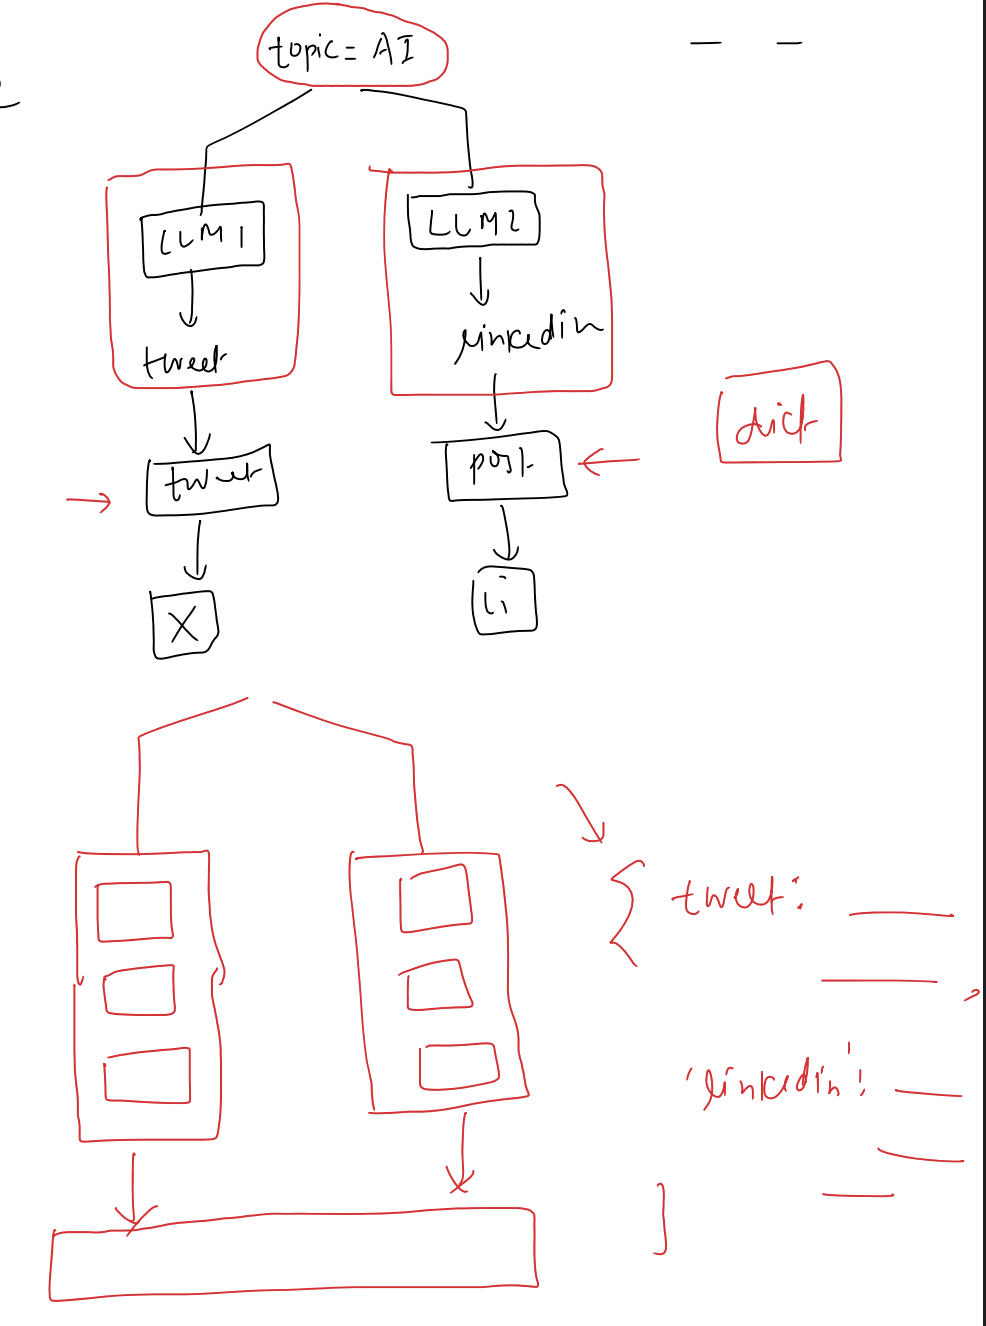

RunnableParallel
- Purpose: To execute multiple runnables in parallel. Each runnable
receives the same input and processes it independently. The output is a dictionary with the results from each runnable.
- When to Use: When you need to perform multiple different operations on the same input simultaneously, like generating a Tweet and a LinkedIn post from the same topic.

### initialize the model and parser

In [1]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
import os

# Load environment variables
load_dotenv()

api_key = os.getenv("Hugging_face_api_token")

# Create LLM endpoint
llm = HuggingFaceEndpoint(
    # repo_id="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    repo_id="mistralai/Mistral-7B-Instruct-v0.2",
    task="text-generation",
    huggingfacehub_api_token=api_key,
)

# Wrap with chat interface
#required two models because we have parallel branch
model1 = ChatHuggingFace(llm=llm)
model2=ChatHuggingFace(llm=llm)

In [2]:
from langchain_core.output_parsers import StrOutputParser

parser=StrOutputParser()


### create prompt templates

In [3]:
from langchain_core.prompts import PromptTemplate
generate_tweet_template=PromptTemplate(
    template="Generate a tweet about {topic}",
    input_variables=["topic"]
)
generate_linkedin_post_template=PromptTemplate(
    template="Generate a LinkedIn post about {topic}",
    input_variables={"topic"}
)

### create chain and invoke chain

In [6]:
from langchain_core.runnables import RunnableParallel
# create two seperate sequences
tweet_chain=generate_tweet_template|model1|parser
linkedin_chain=generate_linkedin_post_template|model1|parser

#now create the parallel chain
parallel_chain=RunnableParallel(
    {
        "tweet":tweet_chain,
        "linkedin":linkedin_chain
    }
)


result=parallel_chain.invoke({
    "topic":"AI"
})


### Output

In [7]:
print(result)
print(type(result))

{'tweet': '💡 Exciting times ahead as #ArtificialIntelligence continues to revolutionize the world! From improving healthcare and education to providing innovative solutions for businesses, the possibilities are endless. Embracing the future, one intelligent step at a time! #AI #FutureIsHere #Innovation #TechTalk 🚀💻 #AIforGood #Progress #TransformativeTech', 'linkedin': "🔮seh has been an fascinating topic of discussion in the tech world lately, and for good reason! 💡AI is revolutionizing industries and transforming the way we live, work, and interact. From chatbots that provide customer service to sophisticated algorithms that diagnose complex medical conditions, the possibilities are endless.\n\nAs we continue to push the boundaries of what's possible with AI, it's important to remember that this technology is only as good as the data it's trained on and the ethics behind its development. That's why it's crucial for businesses and individuals to approach AI with a thoughtful and respon

In [8]:
result.keys()

dict_keys(['tweet', 'linkedin'])

In [9]:
result["tweet"]

'💡 Exciting times ahead as #ArtificialIntelligence continues to revolutionize the world! From improving healthcare and education to providing innovative solutions for businesses, the possibilities are endless. Embracing the future, one intelligent step at a time! #AI #FutureIsHere #Innovation #TechTalk 🚀💻 #AIforGood #Progress #TransformativeTech'

In [10]:
result["linkedin"]

"🔮seh has been an fascinating topic of discussion in the tech world lately, and for good reason! 💡AI is revolutionizing industries and transforming the way we live, work, and interact. From chatbots that provide customer service to sophisticated algorithms that diagnose complex medical conditions, the possibilities are endless.\n\nAs we continue to push the boundaries of what's possible with AI, it's important to remember that this technology is only as good as the data it's trained on and the ethics behind its development. That's why it's crucial for businesses and individuals to approach AI with a thoughtful and responsible mindset. 🧠\n\nAt [Company Name], we're committed to harnessing the power of AI in a way that benefits our customers, employees, and the community. We prioritize transparency, privacy, and ethical decision-making in all of our AI projects. 🌱\n\nWhether you're a seasoned expert or just starting to explore the world of AI, I invite you to join the conversation! Share

### Graphical visualization

In [11]:
parallel_chain.get_graph().print_ascii()

            +-------------------------------+            
            | Parallel<tweet,linkedin>Input |            
            +-------------------------------+            
                  ***               ***                  
               ***                     ***               
             **                           **             
+----------------+                    +----------------+ 
| PromptTemplate |                    | PromptTemplate | 
+----------------+                    +----------------+ 
          *                                   *          
          *                                   *          
          *                                   *          
+-----------------+                  +-----------------+ 
| ChatHuggingFace |                  | ChatHuggingFace | 
+-----------------+                  +-----------------+ 
          *                                   *          
          *                                   *          
          *   